# Regression - Excercise

```In this exercise you will experience with simple features of the linear and logistic regressions, and will get to know some interesting features of those regressions.```

~```Ittai Haran```

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## Coefficients and some more

```We will start by exploring several concepts regarding linear and logistic regression. To that matter, we will prefer working using a generated dataset. Start by generating (using numpy and np.random) the following dataset:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = 0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] + 1$

```Generate 1,000 samples.```

In [37]:
X = np.random.normal(size=(1000,3))
Y = 0.3 * X[:,0] + 0.5 * X[:,1] - 0.7 * X[:,2] + 1

```Train a simple linear regression (sklearn.linear_model.LinearRegression) on the data. What coefficients did you get using your regression? Did you expect those coefficients?```

In [38]:
from sklearn.linear_model import LinearRegression, LogisticRegression
res = LinearRegression().fit(X,Y)
print(res.score(X,Y))

1.0


```We will now conduct a similar experiment, only this time using logistic regression, with minor adjustments:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = (0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] \geq 1)$

```Generate 1,000 samples.```

In [39]:
X = np.random.normal(size=(1000,3))
Y = (0.3 * X[:,0] + 0.5 * X[:,1] - 0.7 * X[:,2] + 1 >= 1)


```Train a simple logistic regression (sklearn.linear_model.LogisticRegression) on the data. What coefficients did you get using your logistic regression? Did you expect those coefficients? Why, or why not?```

In [40]:
res = LogisticRegression().fit(X,Y)
print(res.score(X,Y))
print(res.coef_)

0.995
[[ 2.76437555  4.68460188 -6.37577657]]


```Repeat this experiment, this time with 10,000 samples and 100,000 samples. Did you get different coefficients? Why or why not?```

In [41]:
X = np.random.normal(size=(100000,3))
Y = (0.3 * X[:,0] + 0.5 * X[:,1] - 0.7 * X[:,2] + 1 >= 1)
res = LogisticRegression().fit(X,Y)
print(res.score(X,Y))
print(res.coef_)

0.99963
[[ 13.18579158  22.07179605 -30.84787762]]


## Non-linear linear regressions

```Load the data in func_1_train.csv.
Can be found in: https://drive.google.com/open?id=1y3HtVk0N1q4xYn_qczDcdkZfGpy23z9l```

In [42]:
df = pd.read_csv('resources/func_1_train.csv')

```Draw a scatter plot of y as a function of x. What kind of functions would you like to fit here?```

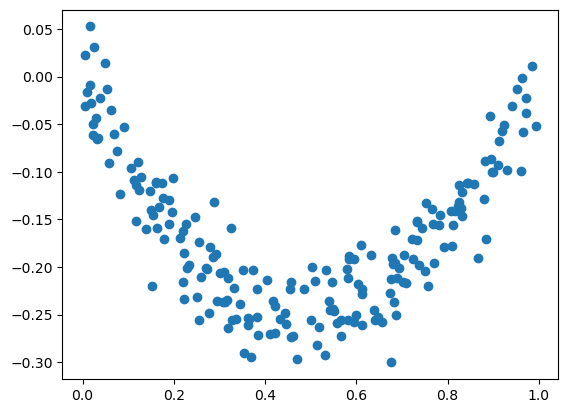

In [43]:
x = np.array(df["x"])
y = np.array(df["y"])
plt.scatter(x,y)
plt.show()

```Try fitting a linear regression. Draw the data points and the function you fitted on the same plot.```

(200, 1)
(200, 1)


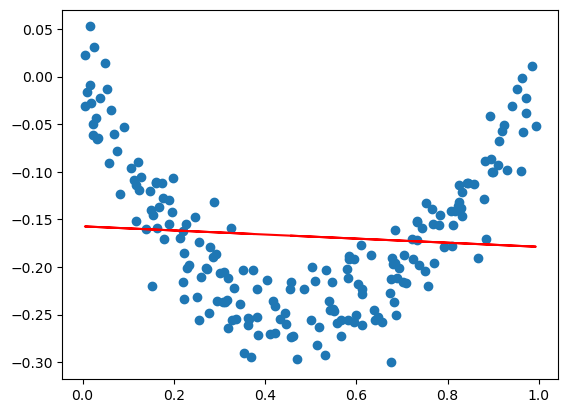

In [44]:
x = x.reshape((-1,1))
y = y.reshape((-1,1))
print(x.shape)
print(y.shape)
res = LinearRegression().fit(x,y)
plt.scatter(x,y)
plt.plot(x, res.predict(x), color='r')
plt.show()

```Let's do some feature extraction. Create a dataset with the features (X, X**2, X**3, ..., X**49). Now try fitting a linear regression using your new dataset. Draw your results on the same graph as before. Judge your results using func_1_test and using the mean squared error metric.```

```Can be found in: https://drive.google.com/open?id=1ipm09QTjVZWFgh-zc70rxWLGPWYEt1Kb```

In [45]:
print(df["x"])

0      0.374147
1      0.124186
2      0.443883
3      0.684252
4      0.656296
         ...   
195    0.005198
196    0.048990
197    0.213106
198    0.009779
199    0.457322
Name: x, Length: 200, dtype: float64


(200,)


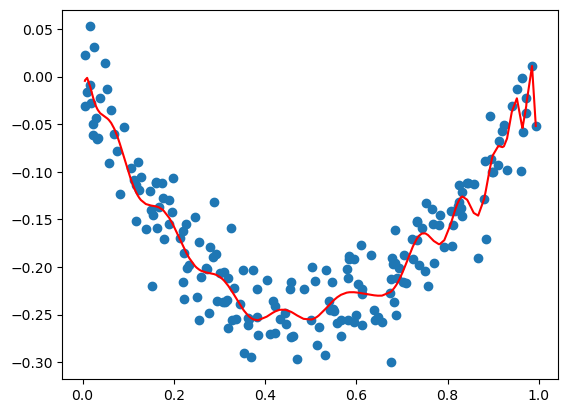

In [46]:
df = pd.read_csv('resources/func_1_train.csv')
features = [f'x**{i}' for i in range(2,50)]
for i, feature in enumerate(features):
    df[feature] = df['x'].apply(lambda x: x**(i+2))
features.append('x')
X_poly = np.array(df[features])
y_poly = np.array(df["y"])
res_poly = LinearRegression().fit(X_poly,y_poly)
plt.scatter(x,y)
print(res_poly.predict(X_poly).shape)
sorted_indices = np.argsort(df["x"])
plt.plot(df["x"].values[sorted_indices], res_poly.predict(X_poly)[sorted_indices], color='r')
plt.show()

```How come you could a model that isn't under fitted? You did still use a linear regression. Can you explain those results? However, your model seemed to be over fitted (why?). Why is that?```

```You can try using a regularized regression to avoid over fitting. Use sklearn.linear_model.Ridge with different alphas until you get nice fit (judge it using your plots and using func_1_test and the mean squared error metric). Could you get better results?```

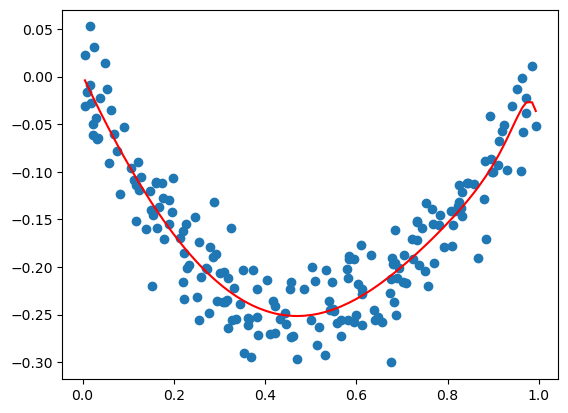

In [47]:
import sklearn.linear_model


df_reg = pd.read_csv("resources/func_1_train.csv")
for i, feature in enumerate(features):
    if feature != 'x':
        df_reg[feature] = df_reg['x'].apply(lambda x: x**(i+2))
# features.append('x')
X_poly_reg = np.array(df_reg[features])
y_poly_reg = np.array(df_reg["y"])
res_poly_reg = sklearn.linear_model.Ridge(alpha=0.001).fit(X_poly_reg,y_poly_reg)
plt.scatter(x,y)
sorted_indices_reg = np.argsort(df_reg["x"])
plt.plot(df_reg["x"].values[sorted_indices_reg], res_poly_reg.predict(X_poly_reg)[sorted_indices_reg], color='r')
plt.show()

## Working on a real life data

```Start by loading house_data.csv. For our current purposes we will need only the numeric columns. Take only the numeric columns, using pandas.DataFrame.dtypes. Use fillna(0) to get rid of nans (the the column Id. can tell why?).```

```Can be found in: https://drive.google.com/open?id=1ID2h8mzjXLRbay5pE0QN1v5-jc86203L```

In [48]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
df = pd.read_csv('resources\house_data.csv')

In [49]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df = numeric_df.fillna(0)
numeric_df = numeric_df.drop(["Id"] ,axis=1)
print(numeric_df.head())


   MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0          60         65.0     8450            7            5       2003   
1          20         80.0     9600            6            8       1976   
2          60         68.0    11250            7            5       2001   
3          70         60.0     9550            7            5       1915   
4          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  ...  WoodDeckSF  \
0          2003       196.0         706           0  ...           0   
1          1976         0.0         978           0  ...         298   
2          2002       162.0         486           0  ...           0   
3          1970         0.0         216           0  ...           0   
4          2000       350.0         655           0  ...         192   

   OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  MiscVal  \
0           61              0     

```We would like to predict the SalePrice columns. Create, using your data, the features dataset and the target dataset. Use sklearn.model_selection.train_test_split and create a train segment of 0.7 of your data and test segment of 0.3 of your data.```

In [50]:
from sklearn.model_selection import train_test_split
y = numeric_df["SalePrice"]
X = numeric_df.drop(columns=["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
regressor = Ridge(alpha=0.001).fit(X_train, y_train)

```Try fitting the best linear regression you can (evaluate yourself using mean squared error). You can also use ridge regression with different alphas.```

In [51]:
y_pred = regressor.predict(X_test)

# Compute Mean Squared Error (MSE) for Linear Regression
mse_lr = mean_squared_error(y_test, y_pred)
print(f"R^2: {regressor.score(X_test, y_test)}")
print(f"Linear Regression MSE: {mse_lr:.2f}")

R^2: 0.8281875998815281
Linear Regression MSE: 1198923037.32


```If you would look closely, you will find out that you dropped the columns LotShape and LandContour. This time try not dropping them, and instead replace them with a 1-hot encoding of them (consider``` [pandas.get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html))```.
Try getting better results on the test segment using your ridge regressions. compare the new results with the old ones.```

In [52]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = ["LotShape", "LandContour"]
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
df_processed = pd.concat([df[numeric_cols], df_encoded], axis=1)
df_processed = df_processed.fillna(0)
y = df_processed["SalePrice"]
X = df_processed.drop(columns=["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ridge Regression with different alpha values
alphas = [0.01, 0.1, 1, 10, 100]
ridge_mse = {}

for alpha in alphas:
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_train, y_train)
    y_pred_ridge = ridge_reg.predict(X_test)
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    ridge_mse[alpha] = mse_ridge
    print(f"Ridge Regression (alpha={alpha}) MSE: {mse_ridge:.2f}")

# Find the best alpha
best_alpha = min(ridge_mse, key=ridge_mse.get)
best_mse = ridge_mse[best_alpha]

print(f"\nBest Ridge Regression model with one-hot encoding: alpha={best_alpha}, MSE={best_mse:.2f}")

Ridge Regression (alpha=0.01) MSE: 1229133880.18
Ridge Regression (alpha=0.1) MSE: 1228499921.28
Ridge Regression (alpha=1) MSE: 1223201303.42
Ridge Regression (alpha=10) MSE: 1205088337.28
Ridge Regression (alpha=100) MSE: 1182152073.05

Best Ridge Regression model with one-hot encoding: alpha=100, MSE=1182152073.05


```Now add more features to your dataframe:```
- ```LotArea in squared meters ( it's currently in units of squared feet)```
- ```1stFlrSF + 2ndFlrSF```
- ```GarageArea**0.5```
- ```LotArea / (BedroomAbvGr+1)```
- ```LotArea / (mean LotArea for houses built in that same year + 1e-5) - you might want to use``` [pandas merge function](https://www.google.com/search?q=pandas+merge&oq=pandas+merge&aqs=chrome..69i57l2j69i59l3j69i60.2080j0j9&sourceid=chrome&ie=UTF-8)
- ```Ranking of LotArea (largest house has 1, the second largest has 2 and so on)```
- ```One hot encoding of LotConfig```

```Are they improve the results?.```

In [54]:
df = pd.read_csv("resources/house_data.csv")

numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = ["LotShape", "LandContour", "LotConfig"]
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

# Create new features
df["LotArea_m2"] = df["LotArea"] * 0.092903  # Convert from sqft to m²
df["TotalFlrSF"] = df["1stFlrSF"] + df["2ndFlrSF"]
df["GarageArea_sqrt"] = df["GarageArea"] ** 0.5
df["LotArea_per_bedroom"] = df["LotArea"] / (df["BedroomAbvGr"] + 1)
mean_lotarea_by_year = df.groupby("YearBuilt")["LotArea"].mean().rename("MeanLotAreaByYear")
df = df.merge(mean_lotarea_by_year, on="YearBuilt", how="left")
df["LotArea_relative"] = df["LotArea"] / (df["MeanLotAreaByYear"] + 1e-5)
df["LotArea_rank"] = df["LotArea"].rank(ascending=False, method="dense")
df = df.drop(columns=["MeanLotAreaByYear"])
numeric_cols = df.select_dtypes(include=['number']).columns
df_processed = pd.concat([df[numeric_cols], df_encoded], axis=1)
df_processed = df_processed.fillna(0)
y = df_processed["SalePrice"]
X = df_processed.drop(columns=["SalePrice"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
alphas = [0.01, 0.1, 1, 10, 100]
ridge_mse = {}

for alpha in alphas:
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(X_train, y_train)
    y_pred_ridge = ridge_reg.predict(X_test)
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    ridge_mse[alpha] = mse_ridge
    print(f"Ridge Regression (alpha={alpha}) MSE: {mse_ridge:.2f}")

# Find the best alpha
best_alpha = min(ridge_mse, key=ridge_mse.get)
best_mse = ridge_mse[best_alpha]

print(f"\nBest Ridge Regression model with extra features: alpha={best_alpha}, MSE={best_mse:.2f}")

Ridge Regression (alpha=0.01) MSE: 1209795379.32
Ridge Regression (alpha=0.1) MSE: 1208960777.39
Ridge Regression (alpha=1) MSE: 1201892646.78
Ridge Regression (alpha=10) MSE: 1175766968.83
Ridge Regression (alpha=100) MSE: 1154789244.29

Best Ridge Regression model with extra features: alpha=100, MSE=1154789244.29


## Bonus

```Think of a feature of your own that improve the result.```

```Use KNN regression (sklearn.neighbors.KNeighborsRegressor).
Compare the results to the linear regression.```